<a href="https://colab.research.google.com/github/liza-zy/fcomp/blob/main/rl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip -q install pyarrow pandas scikit-learn torch

import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cpu


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Версия 1

In [4]:
PROJECT_DIR = Path("/content/drive/MyDrive/fincompass_rl")
DATA_DIR = PROJECT_DIR / "data"
CKPT_DIR = PROJECT_DIR / "checkpoints"
LOG_DIR = PROJECT_DIR / "logs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
list(DATA_DIR.glob("*.parquet"))

[PosixPath('/content/drive/MyDrive/fincompass_rl/data/rl_rewards.parquet'),
 PosixPath('/content/drive/MyDrive/fincompass_rl/data/rl_next_state_features.parquet'),
 PosixPath('/content/drive/MyDrive/fincompass_rl/data/rl_actions.parquet'),
 PosixPath('/content/drive/MyDrive/fincompass_rl/data/rl_target_portfolio_weights.parquet'),
 PosixPath('/content/drive/MyDrive/fincompass_rl/data/rl_state_instrument_features.parquet'),
 PosixPath('/content/drive/MyDrive/fincompass_rl/data/rl_states.parquet'),
 PosixPath('/content/drive/MyDrive/fincompass_rl/data/rl_target_portfolios.parquet'),
 PosixPath('/content/drive/MyDrive/fincompass_rl/data/rl_transitions.parquet')]

In [27]:
states = pd.read_parquet(DATA_DIR / "rl_states.parquet")
actions = pd.read_parquet(DATA_DIR / "rl_actions.parquet")
rewards = pd.read_parquet(DATA_DIR / "rl_rewards.parquet")
next_states = pd.read_parquet(DATA_DIR / "rl_next_state_features.parquet")
transitions = pd.read_parquet(DATA_DIR / "rl_transitions.parquet")

print(states.shape, actions.shape, rewards.shape, next_states.shape, transitions.shape)

(1585, 23) (6340, 6) (6340, 16) (6340, 19) (6340, 5)


In [28]:
df = (
    transitions
    .merge(actions, on=["state_id", "action_id"], how="inner")
    .merge(rewards, on=["state_id", "action_id"], how="inner", suffixes=("", "_r"))
    .merge(states, on="state_id", how="inner", suffixes=("", "_s"))
    .merge(next_states, on=["state_id", "action_id"], how="left")
)

print(df.shape)
df.head()

(6340, 62)


,state_id,action_id,next_state_id,reward_total,done,decision_date,action_label,action_strength,policy_probability,decision_date_r,...,portfolio_realized_vol_3m_next,portfolio_drawdown_3m_next,portfolio_turnover_prev_next,deviation_from_baseline_l1_next,usd_rub_ret_1p_next,brent_ret_1p_next,imoex_ret_1p_next,rgbi_ret_1p_next,gold_ret_1p_next,cbr_key_rate_next
0,1,1,2.0,0.002154,False,2014-01-10,hold_current,NaN,NaN,2014-01-10,...,0.000090,0.0,0.0,0.0,0.004860,0.002789,-0.001550,-0.001284,0.008713,5.5
1,1,2,2.0,0.002154,False,2014-01-10,rebalance_to_baseline,NaN,NaN,2014-01-10,...,0.000090,0.0,0.0,0.0,0.004860,0.002789,-0.001550,-0.001284,0.008713,5.5
2,1,3,2.0,0.002154,False,2014-01-10,decrease_risk_10,0.1,NaN,2014-01-10,...,0.000090,0.0,0.0,0.0,0.004860,0.002789,-0.001550,-0.001284,0.008713,5.5
3,1,4,2.0,0.002154,False,2014-01-10,increase_risk_10,0.1,NaN,2014-01-10,...,0.000090,0.0,0.0,0.0,0.004860,0.002789,-0.001550,-0.001284,0.008713,5.5
4,2,5,3.0,0.002230,False,2014-01-24,hold_current,NaN,NaN,2014-01-24,...,0.000105,0.0,0.0,0.0,-0.006593,0.022204,0.008032,0.000381,-0.005408,5.5


In [29]:
baseline_reward = (
    df[df["action_label"] == "rebalance_to_baseline"][["state_id", "reward_total"]]
    .rename(columns={"reward_total": "baseline_reward_total"})
)

df = df.merge(baseline_reward, on="state_id", how="left")
df["advantage_to_baseline"] = df["reward_total"] - df["baseline_reward_total"]

In [30]:
print(df[["action_label", "reward_total", "baseline_reward_total", "advantage_to_baseline"]].head(20))
print(df.groupby("action_label")["advantage_to_baseline"].agg(["count", "mean", "std", "min", "max"]))

             action_label  reward_total  baseline_reward_total  \
0            hold_current      0.002154               0.002154   
1   rebalance_to_baseline      0.002154               0.002154   
2        decrease_risk_10      0.002154               0.002154   
3        increase_risk_10      0.002154               0.002154   
4            hold_current      0.002230               0.002230   
5   rebalance_to_baseline      0.002230               0.002230   
6        decrease_risk_10      0.002230               0.002230   
7        increase_risk_10      0.002230               0.002230   
8            hold_current      0.002120               0.002120   
9   rebalance_to_baseline      0.002120               0.002120   
10       decrease_risk_10      0.002120               0.002120   
11       increase_risk_10      0.002120               0.002120   
12           hold_current      0.002380               0.002380   
13  rebalance_to_baseline      0.002380               0.002380   
14       d

In [31]:
action_vocab = {a: i for i, a in enumerate(sorted(df["action_label"].dropna().unique()))}
id_to_action = {i: a for a, i in action_vocab.items()}
df["action_idx"] = df["action_label"].map(action_vocab)

print(action_vocab)

{'decrease_risk_10': 0, 'hold_current': 1, 'increase_risk_10': 2, 'rebalance_to_baseline': 3}


In [32]:
state_cols = [
    "portfolio_value",
    "current_equity_weight",
    "current_bond_weight",
    "current_fx_weight",
    "current_metal_weight",
    "current_cash_weight",
    "portfolio_realized_vol_3m",
    "portfolio_drawdown_3m",
    "portfolio_turnover_prev",
    "deviation_from_baseline_l1",
    "target_vol_min",
    "target_vol_max",
    "usd_rub_ret_1p",
    "brent_ret_1p",
    "imoex_ret_1p",
    "rgbi_ret_1p",
    "gold_ret_1p",
    "cbr_key_rate",
]

next_state_cols = [
    "portfolio_value_next",
    "current_equity_weight_next",
    "current_bond_weight_next",
    "current_fx_weight_next",
    "current_metal_weight_next",
    "current_cash_weight_next",
    "portfolio_realized_vol_3m_next",
    "portfolio_drawdown_3m_next",
    "portfolio_turnover_prev_next",
    "deviation_from_baseline_l1_next",
    "usd_rub_ret_1p_next",
    "brent_ret_1p_next",
    "imoex_ret_1p_next",
    "rgbi_ret_1p_next",
    "gold_ret_1p_next",
    "cbr_key_rate_next",
]

next_to_state_map = {
    "portfolio_value_next": "portfolio_value",
    "current_equity_weight_next": "current_equity_weight",
    "current_bond_weight_next": "current_bond_weight",
    "current_fx_weight_next": "current_fx_weight",
    "current_metal_weight_next": "current_metal_weight",
    "current_cash_weight_next": "current_cash_weight",
    "portfolio_realized_vol_3m_next": "portfolio_realized_vol_3m",
    "portfolio_drawdown_3m_next": "portfolio_drawdown_3m",
    "portfolio_turnover_prev_next": "portfolio_turnover_prev",
    "deviation_from_baseline_l1_next": "deviation_from_baseline_l1",
    "usd_rub_ret_1p_next": "usd_rub_ret_1p",
    "brent_ret_1p_next": "brent_ret_1p",
    "imoex_ret_1p_next": "imoex_ret_1p",
    "rgbi_ret_1p_next": "rgbi_ret_1p",
    "gold_ret_1p_next": "gold_ret_1p",
    "cbr_key_rate_next": "cbr_key_rate",
}


In [33]:
for c in state_cols + next_state_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df[state_cols] = df[state_cols].fillna(0.0)
df[next_state_cols] = df[next_state_cols].fillna(0.0)
df["reward_total"] = pd.to_numeric(df["reward_total"], errors="coerce").fillna(0.0)
df["done"] = df["done"].fillna(False).astype(bool)

train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

print(train_df.shape, val_df.shape, test_df.shape)

(4420, 65) (960, 65) (960, 65)


In [34]:
scaler = StandardScaler()

train_X = scaler.fit_transform(train_df[state_cols].values)
val_X = scaler.transform(val_df[state_cols].values) if len(val_df) else np.empty((0, len(state_cols)))
test_X = scaler.transform(test_df[state_cols].values) if len(test_df) else np.empty((0, len(state_cols)))


In [35]:
profile_constant_cols = ["target_vol_min", "target_vol_max"]

def build_next_state_df(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) == 0:
        return pd.DataFrame(columns=state_cols)

    next_part = df[list(next_to_state_map.keys())].rename(columns=next_to_state_map).copy()

    # профильные константы переносим из текущего state
    for col in profile_constant_cols:
        next_part[col] = df[col].values

    # привести порядок колонок ровно к state_cols
    next_part = next_part[state_cols].copy()
    next_part = next_part.fillna(0.0)
    return next_part

train_next_df = build_next_state_df(train_df)
val_next_df = build_next_state_df(val_df) if len(val_df) else pd.DataFrame(columns=state_cols)
test_next_df = build_next_state_df(test_df) if len(test_df) else pd.DataFrame(columns=state_cols)

train_next_X = scaler.transform(train_next_df.values)
val_next_X = scaler.transform(val_next_df.values) if len(val_next_df) else np.empty((0, len(state_cols)))
test_next_X = scaler.transform(test_next_df.values) if len(test_next_df) else np.empty((0, len(state_cols)))

In [36]:
class OfflineRLDataset(Dataset):
    def __init__(self, X, A, R, X_next, D):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.A = torch.tensor(A, dtype=torch.long)
        self.R = torch.tensor(R, dtype=torch.float32)
        self.X_next = torch.tensor(X_next, dtype=torch.float32)
        self.D = torch.tensor(D.astype(np.float32), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.A[idx],
            self.R[idx],
            self.X_next[idx],
            self.D[idx],
        )

In [37]:
train_ds = OfflineRLDataset(
    train_X,
    train_df["action_idx"].values,
    train_df["reward_total"].values,
    train_next_X,
    train_df["done"].values,
)

val_ds = OfflineRLDataset(
    val_X,
    val_df["action_idx"].values if len(val_df) else np.array([], dtype=int),
    val_df["reward_total"].values if len(val_df) else np.array([], dtype=float),
    val_next_X,
    val_df["done"].values if len(val_df) else np.array([], dtype=bool),
) if len(val_df) else None

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False) if val_ds else None

In [38]:
class QNet(nn.Module):
    def __init__(self, input_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    def forward(self, x):
        return self.net(x)

In [39]:
n_actions = len(action_vocab)
q_net = QNet(len(state_cols), n_actions).to(DEVICE)
target_net = QNet(len(state_cols), n_actions).to(DEVICE)
target_net.load_state_dict(q_net.state_dict())

optimizer = torch.optim.Adam(q_net.parameters(), lr=1e-3)
loss_fn = nn.SmoothL1Loss()

gamma = 0.99
target_update_every = 2

In [40]:
LAST_CKPT = CKPT_DIR / "offline_dqn_last.pt"
BEST_CKPT = CKPT_DIR / "offline_dqn_best.pt"
HIST_CSV = LOG_DIR / "offline_dqn_history.csv"

best_val_loss = float("inf")
history = []
start_epoch = 0

if LAST_CKPT.exists():
    ckpt = torch.load(LAST_CKPT, map_location=DEVICE)
    q_net.load_state_dict(ckpt["q_net"])
    target_net.load_state_dict(ckpt["target_net"])
    optimizer.load_state_dict(ckpt["optimizer"])
    best_val_loss = ckpt["best_val_loss"]
    start_epoch = ckpt["epoch"] + 1
    print("Resumed from epoch", start_epoch)

In [41]:
def train_epoch():
    q_net.train()
    total_loss = 0.0
    total_n = 0

    for x, a, r, x_next, d in train_loader:
        x = x.to(DEVICE)
        a = a.to(DEVICE)
        r = r.to(DEVICE)
        x_next = x_next.to(DEVICE)
        d = d.to(DEVICE)

        q_values = q_net(x)
        q_sa = q_values.gather(1, a.unsqueeze(1)).squeeze(1)

        y = r

        loss = loss_fn(q_sa, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = len(x)
        total_loss += loss.item() * bs
        total_n += bs

    return total_loss / max(total_n, 1)


@torch.no_grad()
def eval_epoch(loader):
    q_net.eval()
    total_loss = 0.0
    total_n = 0

    for x, a, r, x_next, d in loader:
        x = x.to(DEVICE)
        a = a.to(DEVICE)
        r = r.to(DEVICE)
        x_next = x_next.to(DEVICE)
        d = d.to(DEVICE)

        q_values = q_net(x)
        q_sa = q_values.gather(1, a.unsqueeze(1)).squeeze(1)

        next_q = target_net(x_next).max(dim=1).values
        y = r + gamma * (1.0 - d) * next_q

        loss = loss_fn(q_sa, y)

        bs = len(x)
        total_loss += loss.item() * bs
        total_n += bs

    return total_loss / max(total_n, 1)

In [42]:
EPOCHS = 30

for epoch in range(start_epoch, EPOCHS):
    train_loss = train_epoch()
    val_loss = eval_epoch(val_loader) if val_loader else np.nan

    if epoch % target_update_every == 0:
        target_net.load_state_dict(q_net.state_dict())

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": float(val_loss) if not np.isnan(val_loss) else None,
    }
    history.append(row)

    torch.save(
        {
            "epoch": epoch,
            "q_net": q_net.state_dict(),
            "target_net": target_net.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "action_vocab": action_vocab,
            "state_cols": state_cols,
        },
        LAST_CKPT,
    )

    if val_loader and val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "epoch": epoch,
                "q_net": q_net.state_dict(),
                "target_net": target_net.state_dict(),
                "optimizer": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "action_vocab": action_vocab,
                "state_cols": state_cols,
            },
            BEST_CKPT,
        )

    pd.DataFrame(history).to_csv(HIST_CSV, index=False)
    print(row)

{'epoch': 0, 'train_loss': 0.009897263512875025, 'val_loss': 0.0017536267172545195}
{'epoch': 1, 'train_loss': 0.008279144962853436, 'val_loss': 0.0017280102086563904}
{'epoch': 2, 'train_loss': 0.007815531298004058, 'val_loss': 0.0018689362021783987}
{'epoch': 3, 'train_loss': 0.007486223057755248, 'val_loss': 0.0016886297923823198}
{'epoch': 4, 'train_loss': 0.007231122019650136, 'val_loss': 0.0016571585942680637}
{'epoch': 5, 'train_loss': 0.006869939528616373, 'val_loss': 0.0021617130376398565}
{'epoch': 6, 'train_loss': 0.0065984220530551215, 'val_loss': 0.001971631171181798}
{'epoch': 7, 'train_loss': 0.00638226199878287, 'val_loss': 0.002929176234950622}
{'epoch': 8, 'train_loss': 0.0061809176902552195, 'val_loss': 0.002434443791086475}
{'epoch': 9, 'train_loss': 0.005567682179521213, 'val_loss': 0.001921750403319796}
{'epoch': 10, 'train_loss': 0.005153314984399336, 'val_loss': 0.0028662193566560746}
{'epoch': 11, 'train_loss': 0.004936637953756065, 'val_loss': 0.00245694293019

In [43]:
@torch.no_grad()
def predict_action(df_states: pd.DataFrame):
    X = scaler.transform(df_states[state_cols].fillna(0.0).values)
    x = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    q = q_net(x)
    a = q.argmax(dim=1).cpu().numpy()
    return [id_to_action[i] for i in a]

sample_actions = predict_action(test_df.head(20))
sample_actions[:10]

['increase_risk_10',
 'increase_risk_10',
 'increase_risk_10',
 'increase_risk_10',
 'increase_risk_10',
 'increase_risk_10',
 'increase_risk_10',
 'increase_risk_10',
 'increase_risk_10',
 'increase_risk_10']

In [46]:
df.groupby("action_label")["reward_total"].agg(["count", "mean", "std", "min", "max"])

,count,mean,std,min,max
action_label,,,,,
decrease_risk_10,1585,-0.005535,0.109097,-2.818073,0.116263
hold_current,1585,-0.008399,0.140450,-3.846447,0.096894
increase_risk_10,1585,-0.010929,0.155260,-3.846447,0.104065
rebalance_to_baseline,1585,-0.007437,0.125224,-3.204738,0.152977


## Версия 2

In [3]:
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/fincompass_rl/data"

states = pd.read_parquet(f"{BASE_DIR}/rl_states.parquet")
actions = pd.read_parquet(f"{BASE_DIR}/rl_actions.parquet")
rewards = pd.read_parquet(f"{BASE_DIR}/rl_rewards.parquet")
next_states = pd.read_parquet(f"{BASE_DIR}/rl_next_state_features.parquet")

In [4]:
df = (
    states
    .merge(actions, on=["state_id", "decision_date"], how="inner")
    .merge(rewards, on=["state_id", "action_id", "decision_date"], how="inner")
    .merge(next_states, on=["state_id", "action_id"], how="inner")
)

In [5]:
df.shape, df.head()

((6340, 57),
    state_id decision_date  split  risk_profile_id  baseline_portfolio_id  \
 0         1    2014-01-10  train                0                      1   
 1         1    2014-01-10  train                0                      1   
 2         1    2014-01-10  train                0                      1   
 3         1    2014-01-10  train                0                      1   
 4         2    2014-01-24  train                0                     11   
 
    portfolio_value  current_equity_weight  current_bond_weight  \
 0         1.000000                    0.0                  0.0   
 1         1.000000                    0.0                  0.0   
 2         1.000000                    0.0                  0.0   
 3         1.000000                    0.0                  0.0   
 4         1.002154                    0.0                  0.0   
 
    current_fx_weight  current_metal_weight  ...  \
 0                0.0                   0.0  ...   
 1             

In [6]:
action_vocab = {
    "hold_current": 0,
    "rebalance_to_baseline": 1,
    "decrease_risk_10": 2,
    "increase_risk_10": 3,
}

df["action_idx"] = df["action_label"].map(action_vocab)
df["done"] = df["next_decision_date_x"].isna()

In [7]:
print(df.columns.tolist())

['state_id', 'decision_date', 'split', 'risk_profile_id', 'baseline_portfolio_id', 'portfolio_value', 'current_equity_weight', 'current_bond_weight', 'current_fx_weight', 'current_metal_weight', 'current_cash_weight', 'portfolio_realized_vol_3m', 'portfolio_drawdown_3m', 'portfolio_turnover_prev', 'deviation_from_baseline_l1', 'target_vol_min', 'target_vol_max', 'usd_rub_ret_1p', 'brent_ret_1p', 'imoex_ret_1p', 'rgbi_ret_1p', 'gold_ret_1p', 'cbr_key_rate', 'action_id', 'action_label', 'action_strength', 'policy_probability', 'next_decision_date_x', 'gross_return_1p', 'net_return_1p', 'turnover', 'transaction_cost', 'realized_vol_1p', 'realized_drawdown_1p', 'risk_band_violation', 'reward_return_component', 'reward_risk_penalty', 'reward_turnover_penalty', 'reward_band_penalty', 'reward_total', 'next_decision_date_y', 'portfolio_value_next', 'current_equity_weight_next', 'current_bond_weight_next', 'current_fx_weight_next', 'current_metal_weight_next', 'current_cash_weight_next', 'portf

In [8]:
df["action_idx"].value_counts(dropna=False)

,count
action_idx,
0,1585
1,1585
2,1585
3,1585


In [9]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

In [10]:
state_cols = [
    "current_equity_weight",
    "current_bond_weight",
    "current_fx_weight",
    "current_metal_weight",
    "current_cash_weight",
    "portfolio_realized_vol_3m",
    "portfolio_drawdown_3m",
    "portfolio_turnover_prev",
    "deviation_from_baseline_l1",
    "target_vol_min",
    "target_vol_max",
    "usd_rub_ret_1p",
    "brent_ret_1p",
    "imoex_ret_1p",
    "rgbi_ret_1p",
    "gold_ret_1p",
    "cbr_key_rate",
]

In [11]:
next_to_state_map = {
    "current_equity_weight_next": "current_equity_weight",
    "current_bond_weight_next": "current_bond_weight",
    "current_fx_weight_next": "current_fx_weight",
    "current_metal_weight_next": "current_metal_weight",
    "current_cash_weight_next": "current_cash_weight",
    "portfolio_realized_vol_3m_next": "portfolio_realized_vol_3m",
    "portfolio_drawdown_3m_next": "portfolio_drawdown_3m",
    "portfolio_turnover_prev_next": "portfolio_turnover_prev",
    "deviation_from_baseline_l1_next": "deviation_from_baseline_l1",
    "usd_rub_ret_1p_next": "usd_rub_ret_1p",
    "brent_ret_1p_next": "brent_ret_1p",
    "imoex_ret_1p_next": "imoex_ret_1p",
    "rgbi_ret_1p_next": "rgbi_ret_1p",
    "gold_ret_1p_next": "gold_ret_1p",
    "cbr_key_rate_next": "cbr_key_rate",
}

In [12]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

train_X = scaler.fit_transform(train_df[state_cols].values)
val_X = scaler.transform(val_df[state_cols].values)
test_X = scaler.transform(test_df[state_cols].values)

train_next_df = train_df[list(next_to_state_map.keys())].rename(columns=next_to_state_map)
val_next_df = val_df[list(next_to_state_map.keys())].rename(columns=next_to_state_map)
test_next_df = test_df[list(next_to_state_map.keys())].rename(columns=next_to_state_map)

# добавляем state-константы профиля
for col in ["target_vol_min", "target_vol_max"]:
    train_next_df[col] = train_df[col].values
    val_next_df[col] = val_df[col].values
    test_next_df[col] = test_df[col].values

train_next_X = scaler.transform(train_next_df[state_cols].values)
val_next_X = scaler.transform(val_next_df[state_cols].values)
test_next_X = scaler.transform(test_next_df[state_cols].values)

In [13]:
train_reward_mean = train_df["reward_total"].mean()
train_reward_std = train_df["reward_total"].std()

def norm_reward(s):
    return ((s - train_reward_mean) / (train_reward_std + 1e-8)).clip(-5, 5)

train_r = norm_reward(train_df["reward_total"]).values
val_r = norm_reward(val_df["reward_total"]).values
test_r = norm_reward(test_df["reward_total"]).values

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader

class OfflineRLDataset(Dataset):
    def __init__(self, x, a, r, x_next, d):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.a = torch.tensor(a, dtype=torch.long)
        self.r = torch.tensor(r, dtype=torch.float32)
        self.x_next = torch.tensor(x_next, dtype=torch.float32)
        self.d = torch.tensor(d, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.a[idx], self.r[idx], self.x_next[idx], self.d[idx]

train_ds = OfflineRLDataset(
    train_X,
    train_df["action_idx"].values,
    train_r,
    train_next_X,
    train_df["done"].values,
)

val_ds = OfflineRLDataset(
    val_X,
    val_df["action_idx"].values,
    val_r,
    val_next_X,
    val_df["done"].values,
)

test_ds = OfflineRLDataset(
    test_X,
    test_df["action_idx"].values,
    test_r,
    test_next_X,
    test_df["done"].values,
)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

In [15]:
import torch.nn as nn

class QNet(nn.Module):
    def __init__(self, input_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.net(x)

In [16]:
q_net = QNet(len(state_cols), len(action_vocab)).to(DEVICE)
optimizer = torch.optim.Adam(
    q_net.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)
loss_fn = nn.MSELoss()

In [17]:
def train_epoch():
    q_net.train()
    total_loss = 0.0
    total_n = 0

    for x, a, r, x_next, d in train_loader:
        x = x.to(DEVICE)
        a = a.to(DEVICE)
        r = r.to(DEVICE)

        q_values = q_net(x)
        q_sa = q_values.gather(1, a.unsqueeze(1)).squeeze(1)

        loss = loss_fn(q_sa, r)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = len(x)
        total_loss += loss.item() * bs
        total_n += bs

    return total_loss / max(total_n, 1)

In [18]:
def eval_epoch(loader):
    q_net.eval()
    total_loss = 0.0
    total_n = 0

    with torch.no_grad():
        for x, a, r, x_next, d in loader:
            x = x.to(DEVICE)
            a = a.to(DEVICE)
            r = r.to(DEVICE)

            q_values = q_net(x)
            q_sa = q_values.gather(1, a.unsqueeze(1)).squeeze(1)

            loss = loss_fn(q_sa, r)

            bs = len(x)
            total_loss += loss.item() * bs
            total_n += bs

    return total_loss / max(total_n, 1)

In [19]:
history = []

EPOCHS = 30
best_val_loss = float("inf")
best_state = None
patience = 5
bad_epochs = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch()
    val_loss = eval_epoch(val_loader)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    }
    history.append(row)
    print(row)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in q_net.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state is not None:
    q_net.load_state_dict(best_state)

{'epoch': 0, 'train_loss': 0.33377931970276986, 'val_loss': 0.04596520811319351}
{'epoch': 1, 'train_loss': 0.3175769082021929, 'val_loss': 0.04438579579194387}
{'epoch': 2, 'train_loss': 0.3081784599776721, 'val_loss': 0.044169111053148906}
{'epoch': 3, 'train_loss': 0.3017997198717087, 'val_loss': 0.0449957067767779}
{'epoch': 4, 'train_loss': 0.29181855111572536, 'val_loss': 0.04446233361959458}
{'epoch': 5, 'train_loss': 0.28416781954096454, 'val_loss': 0.04507501025994619}
{'epoch': 6, 'train_loss': 0.27212019118383457, 'val_loss': 0.04762815982103348}
{'epoch': 7, 'train_loss': 0.2627399707272042, 'val_loss': 0.049255700409412385}
Early stopping at epoch 7


In [20]:
import numpy as np

q_net.eval()
with torch.no_grad():
    x = torch.tensor(test_X, dtype=torch.float32).to(DEVICE)
    q = q_net(x).cpu().numpy()

pred_action_idx = q.argmax(axis=1)
inv_vocab = {v: k for k, v in action_vocab.items()}
pred_actions = [inv_vocab[i] for i in pred_action_idx]

from collections import Counter
Counter(pred_actions)

Counter({'increase_risk_10': 184,
         'decrease_risk_10': 320,
         'rebalance_to_baseline': 156,
         'hold_current': 300})

## Бэктест

In [28]:
states = pd.read_parquet(f"{BASE_DIR}/rl_states.parquet")
actions = pd.read_parquet(f"{BASE_DIR}/rl_actions.parquet")
target_portfolios = pd.read_parquet(f"{BASE_DIR}/rl_target_portfolios.parquet")
target_weights = pd.read_parquet(f"{BASE_DIR}/rl_target_portfolio_weights.parquet")
market_prices = pd.read_parquet(f"{BASE_DIR}/market_prices.parquet")

In [29]:
test_states = states[states["split"] == "test"].copy()
test_states = test_states.sort_values(["risk_profile_id", "decision_date", "state_id"]).reset_index(drop=True)

test_states["decision_date"] = pd.to_datetime(test_states["decision_date"])

In [30]:
market_prices["date"] = pd.to_datetime(market_prices["date"])

price_pivot = market_prices.pivot_table(
    index="date",
    columns="instrument_id",
    values="close",
    aggfunc="last"
).sort_index()

ret_pivot = price_pivot.pct_change()

/tmp/ipykernel_18942/2860901044.py:10: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_pivot = price_pivot.pct_change()


In [31]:
action_df = (
    actions.merge(
        target_portfolios,
        on=["state_id", "action_id", "decision_date"],
        how="inner"
    )
)

target_weights_by_tp = {
    int(tp_id): grp.set_index("instrument_id")["target_weight"].astype(float)
    for tp_id, grp in target_weights.groupby("target_portfolio_id")
}

In [32]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
inv_vocab = {v: k for k, v in action_vocab.items()}

def predict_action(row_df):
    x = scaler.transform(row_df[state_cols].values)
    x_t = torch.tensor(x, dtype=torch.float32).to(DEVICE)

    q_net.eval()
    with torch.no_grad():
        q = q_net(x_t).cpu().numpy()

    action_idx = int(q.argmax(axis=1)[0])
    return inv_vocab[action_idx]

In [33]:
def portfolio_period_return(weights: pd.Series, start_date, end_date):
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    if start_date not in price_pivot.index or end_date not in price_pivot.index:
        # fallback: ближайшие <= даты
        start_idx = price_pivot.index[price_pivot.index <= start_date]
        end_idx = price_pivot.index[price_pivot.index <= end_date]
        if len(start_idx) == 0 or len(end_idx) == 0:
            return 0.0
        start_date = start_idx.max()
        end_date = end_idx.max()

    gross = 0.0
    for iid, w in weights.items():
        if iid not in price_pivot.columns:
            continue
        p0 = price_pivot.loc[start_date, iid]
        p1 = price_pivot.loc[end_date, iid]
        if pd.notna(p0) and pd.notna(p1) and p0 > 0:
            gross += float(w) * (p1 / p0 - 1.0)
    return gross

In [34]:
state_instr = pd.read_parquet(f"{BASE_DIR}/rl_state_instrument_features.parquet")

current_weights_by_state = {
    int(state_id): grp.set_index("instrument_id")["current_weight"].astype(float)
    for state_id, grp in state_instr.groupby("state_id")
}

In [35]:
def backtest_hold_initial(risk_profile_id: int, initial_value: float = 1.0):
    df = test_states[test_states["risk_profile_id"] == risk_profile_id].copy()
    df = df.sort_values("decision_date").reset_index(drop=True)

    first_state_id = int(df.iloc[0]["state_id"])
    weights = current_weights_by_state[first_state_id].copy()
    weights = weights[weights > 1e-12]
    weights = weights / weights.sum()

    values = [initial_value]
    dates = [df.iloc[0]["decision_date"]]

    value = initial_value
    for i in range(len(df) - 1):
        d0 = df.iloc[i]["decision_date"]
        d1 = df.iloc[i + 1]["decision_date"]

        r = portfolio_period_return(weights, d0, d1)
        value *= (1.0 + r)

        values.append(value)
        dates.append(d1)

    return pd.DataFrame({"date": dates, "value": values, "strategy": "hold_initial"})

In [43]:
print(market_prices.columns.tolist())

['date', 'instrument_id', 'open', 'high', 'low', 'close', 'volume', 'value_traded', 'num_trades', 'is_traded']


In [36]:
def backtest_imoex_from_states(risk_profile_id: int, initial_value: float = 1.0):
    df = test_states[test_states["risk_profile_id"] == risk_profile_id].copy()
    df = df.sort_values("decision_date").reset_index(drop=True)

    values = [initial_value]
    dates = [df.iloc[0]["decision_date"]]

    value = initial_value
    for i in range(len(df) - 1):
        r = float(df.iloc[i + 1]["imoex_ret_1p"])
        value *= (1.0 + r)
        values.append(value)
        dates.append(df.iloc[i + 1]["decision_date"])

    return pd.DataFrame({"date": dates, "value": values, "strategy": "imoex_hold"})

In [44]:
def get_period_return_map(price_pivot: pd.DataFrame, start_date, end_date):
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    start_idx = price_pivot.index[price_pivot.index <= start_date]
    end_idx = price_pivot.index[price_pivot.index <= end_date]

    if len(start_idx) == 0 or len(end_idx) == 0:
        return {}

    start_date = start_idx.max()
    end_date = end_idx.max()

    p0 = price_pivot.loc[start_date]
    p1 = price_pivot.loc[end_date]

    valid = (p0.notna()) & (p1.notna()) & (p0 > 0)
    rets = (p1[valid] / p0[valid] - 1.0).to_dict()

    return {int(k): float(v) for k, v in rets.items()}

In [45]:
def compute_deposit_return_simple(cbr_key_rate, date_from, date_to):
    if pd.isna(cbr_key_rate):
        return 0.0

    rate = float(cbr_key_rate)
    if rate > 1.0:
        rate = rate / 100.0

    days = max((pd.Timestamp(date_to) - pd.Timestamp(date_from)).days, 1)
    return rate * days / 365.0

In [46]:
def portfolio_period_return_from_map(weights: pd.Series, ret_map: dict, deposit_id: int, deposit_ret: float):
    gross = 0.0
    for iid, w in weights.items():
        iid = int(iid)
        w = float(w)
        r = deposit_ret if iid == deposit_id else float(ret_map.get(iid, 0.0))
        gross += w * r
    return gross

In [47]:
def drift_weights_forward_local(weights: pd.Series, ret_map: dict, deposit_id: int, deposit_ret: float):
    grown = {}
    for iid, w in weights.items():
        iid = int(iid)
        w = float(w)
        r = deposit_ret if iid == deposit_id else float(ret_map.get(iid, 0.0))
        grown[iid] = w * (1.0 + r)

    total = sum(grown.values())
    if total <= 1e-12:
        return weights.copy()

    out = pd.Series({k: v / total for k, v in grown.items()}, dtype=float)
    out = out[out > 1e-12]
    out = out / out.sum()
    return out

In [55]:
def make_model_state_row(base_row: pd.DataFrame, risky_weights: pd.Series, cash_weight: float, asset_class_by_id: dict):
    row = base_row.copy()

    eq = 0.0
    bond = 0.0
    fx = 0.0
    metal = 0.0

    for iid, w in risky_weights.items():
        iid = int(iid)
        cls = asset_class_by_id.get(iid, None)

        if cls == "equity":
            eq += float(w)
        elif cls == "bond":
            bond += float(w)
        elif cls == "fx":
            fx += float(w)
        elif cls == "metal":
            metal += float(w)

    row.loc[:, "current_equity_weight"] = eq
    row.loc[:, "current_bond_weight"] = bond
    row.loc[:, "current_fx_weight"] = fx
    row.loc[:, "current_metal_weight"] = metal
    row.loc[:, "current_cash_weight"] = float(cash_weight)

    return row

In [56]:
def portfolio_period_return_with_cash(risky_weights: pd.Series, cash_weight: float, ret_map: dict, deposit_ret: float):
    gross = 0.0

    for iid, w in risky_weights.items():
        iid = int(iid)
        gross += float(w) * float(ret_map.get(iid, 0.0))

    gross += float(cash_weight) * float(deposit_ret)
    return gross

In [57]:
def drift_weights_forward_with_cash(risky_weights: pd.Series, cash_weight: float, ret_map: dict, deposit_ret: float):
    grown = {}

    for iid, w in risky_weights.items():
        iid = int(iid)
        grown[iid] = float(w) * (1.0 + float(ret_map.get(iid, 0.0)))

    cash_grown = float(cash_weight) * (1.0 + float(deposit_ret))

    total = cash_grown + sum(grown.values())
    if total <= 1e-12:
        return risky_weights.copy(), cash_weight

    risky_next = pd.Series({k: v / total for k, v in grown.items()}, dtype=float)
    risky_next = risky_next[risky_next > 1e-12]
    cash_next = cash_grown / total

    s = risky_next.sum()
    if s + cash_next > 0:
        # на всякий случай нормируем
        risky_next = risky_next / (s + cash_next)
        cash_next = cash_next / (s + cash_next)

    return risky_next, cash_next

In [50]:
asset_cls_df = pd.read_parquet(f"{BASE_DIR}/instrument_asset_class.parquet")
asset_class_by_id = (
    asset_cls_df
    .drop_duplicates(subset=["instrument_id"])
    .set_index("instrument_id")["asset_class"]
    .to_dict()
)

In [58]:
TCOST = 15 / 10000.0

def backtest_rl_policy_closed_loop(risk_profile_id: int, initial_value: float = 1.0):
    df = test_states[test_states["risk_profile_id"] == risk_profile_id].copy()
    df = df.sort_values("decision_date").reset_index(drop=True)
    df["decision_date"] = pd.to_datetime(df["decision_date"])

    values = [initial_value]
    dates = [df.iloc[0]["decision_date"]]
    chosen_actions = []
    turnovers = []

    value = initial_value

    # стартовое состояние
    first_state_id = int(df.iloc[0]["state_id"])
    current_full_w = current_weights_by_state[first_state_id].copy()
    current_full_w = current_full_w[current_full_w > 1e-12]

    # cash берем из rl_states, risky - из instrument weights
    cash_w = float(df.iloc[0]["current_cash_weight"])
    risky_w = current_full_w.copy()

    # если risky_w вдруг суммируется больше чем 1-cash, нормализуем
    risky_sum = float(risky_w.sum())
    if risky_sum > 1e-12:
        risky_w = risky_w / risky_sum * max(0.0, 1.0 - cash_w)
    else:
        risky_w = pd.Series(dtype=float)

    for i in range(len(df) - 1):
        base_row = df.iloc[[i]].copy()
        state_id = int(base_row.iloc[0]["state_id"])
        d0 = df.iloc[i]["decision_date"]
        d1 = df.iloc[i + 1]["decision_date"]

        # текущее состояние для модели собираем из фактических весов
        model_row = make_model_state_row(
            base_row=base_row,
            risky_weights=risky_w,
            cash_weight=cash_w,
            asset_class_by_id=asset_class_by_id,
        )

        pred_action = predict_action(model_row)
        chosen_actions.append(pred_action)

        action_row = action_df[
            (action_df["state_id"] == state_id) &
            (action_df["action_label"] == pred_action)
        ].iloc[0]

        tp_id = int(action_row["target_portfolio_id"])

        # risky target weights
        target_risky_w = target_weights_by_tp.get(tp_id, pd.Series(dtype=float)).copy()
        target_risky_w = target_risky_w[target_risky_w > 1e-12]

        # cash weight берем из rl_target_portfolios
        target_cash_w = float(action_row["cash_weight"])

        target_risky_sum = float(target_risky_w.sum())
        if target_risky_sum > 1e-12:
            target_risky_w = target_risky_w / target_risky_sum * max(0.0, 1.0 - target_cash_w)
        else:
            target_risky_w = pd.Series(dtype=float)

        # turnover: risky L1 + изменение cash
        idx = sorted(set(risky_w.index) | set(target_risky_w.index))
        rw = risky_w.reindex(idx).fillna(0.0)
        tw = target_risky_w.reindex(idx).fillna(0.0)

        turnover = float((rw - tw).abs().sum() + abs(cash_w - target_cash_w))
        turnovers.append(turnover)

        # доходности на период
        ret_map = get_period_return_map(price_pivot, d0, d1)
        deposit_ret = compute_deposit_return_simple(
            cbr_key_rate=float(base_row.iloc[0]["cbr_key_rate"]),
            date_from=d0,
            date_to=d1,
        )

        gross_r = portfolio_period_return_with_cash(
            risky_weights=target_risky_w,
            cash_weight=target_cash_w,
            ret_map=ret_map,
            deposit_ret=deposit_ret,
        )
        net_r = gross_r - turnover * TCOST

        value *= (1.0 + net_r)

        # closed-loop: target -> drift -> becomes next current
        risky_w, cash_w = drift_weights_forward_with_cash(
            risky_weights=target_risky_w,
            cash_weight=target_cash_w,
            ret_map=ret_map,
            deposit_ret=deposit_ret,
        )

        values.append(value)
        dates.append(d1)

    result = pd.DataFrame({
        "date": dates,
        "value": values,
        "strategy": "rl_policy_closed_loop",
    })

    meta = {
        "chosen_actions": Counter(chosen_actions),
        "avg_turnover": float(np.mean(turnovers)) if turnovers else 0.0,
    }

    return result, meta

In [59]:
TCOST = 15 / 10000.0

def backtest_rl_policy(risk_profile_id: int, initial_value: float = 1.0):
    df = test_states[test_states["risk_profile_id"] == risk_profile_id].copy()
    df = df.sort_values("decision_date").reset_index(drop=True)

    values = [initial_value]
    dates = [df.iloc[0]["decision_date"]]
    chosen_actions = []

    value = initial_value

    for i in range(len(df) - 1):
        row = df.iloc[[i]].copy()
        state_id = int(row.iloc[0]["state_id"])
        d0 = row.iloc[0]["decision_date"]
        d1 = df.iloc[i + 1]["decision_date"]

        pred_action = predict_action(row)
        chosen_actions.append(pred_action)

        action_row = action_df[
            (action_df["state_id"] == state_id) &
            (action_df["action_label"] == pred_action)
        ].iloc[0]

        tp_id = int(action_row["target_portfolio_id"])
        weights = target_weights_by_tp[tp_id].copy()
        weights = weights[weights > 1e-12]
        weights = weights / weights.sum()

        # turnover относительно текущего current portfolio данного state
        current_w = current_weights_by_state[state_id].copy()
        current_w = current_w[current_w > 1e-12]
        if len(current_w) > 0:
            current_w = current_w / current_w.sum()

        idx = sorted(set(current_w.index) | set(weights.index))
        cw = current_w.reindex(idx).fillna(0.0)
        tw = weights.reindex(idx).fillna(0.0)
        turnover = (cw - tw).abs().sum()

        gross_r = portfolio_period_return(weights, d0, d1)
        net_r = gross_r - turnover * TCOST

        value *= (1.0 + net_r)

        values.append(value)
        dates.append(d1)

    result = pd.DataFrame({"date": dates, "value": values, "strategy": "rl_policy"})
    return result, Counter(chosen_actions)

In [61]:
hold_df = backtest_hold_initial(risk_profile_id=2)
#imoex_df = backtest_imoex_from_states(risk_profile_id=2)
rl_df, rl_actions_counter = backtest_rl_policy_closed_loop(risk_profile_id=2)

print(rl_actions_counter)

{'chosen_actions': Counter({'hold_current': 24, 'decrease_risk_10': 13, 'rebalance_to_baseline': 7, 'increase_risk_10': 3}), 'avg_turnover': 0.4811374943900211}


In [39]:
plot_df = pd.concat([hold_df, rl_df], ignore_index=True)
plot_df.head()

,date,value,strategy
0,2024-05-03,1.000000,hold_initial
1,2024-05-17,1.008808,hold_initial
2,2024-05-31,0.990003,hold_initial
3,2024-06-14,0.993482,hold_initial
4,2024-06-28,0.989308,hold_initial


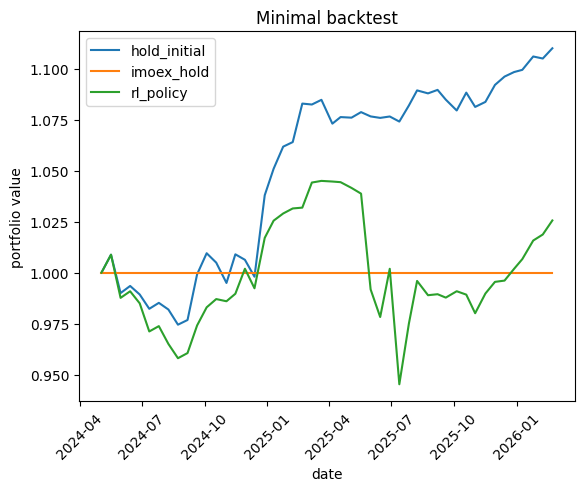

In [62]:
import matplotlib.pyplot as plt

for name, grp in plot_df.groupby("strategy"):
    plt.plot(grp["date"], grp["value"], label=name)

plt.legend()
plt.title("Minimal backtest")
plt.xlabel("date")
plt.ylabel("portfolio value")
plt.xticks(rotation=45)
plt.show()

прогон по всем риск-профилям

In [63]:
all_rl_results = []
all_rl_meta = []

for rp in sorted(test_states["risk_profile_id"].dropna().unique()):
    rl_df, rl_meta = backtest_rl_policy_closed_loop(risk_profile_id=int(rp), initial_value=1.0)
    rl_df["risk_profile_id"] = int(rp)

    all_rl_results.append(rl_df)
    all_rl_meta.append({
        "risk_profile_id": int(rp),
        "avg_turnover": rl_meta["avg_turnover"],
        "chosen_actions": dict(rl_meta["chosen_actions"]),
    })

rl_all_df = pd.concat(all_rl_results, ignore_index=True)
rl_meta_df = pd.DataFrame(all_rl_meta)

print(rl_meta_df)

   risk_profile_id  avg_turnover  \
0                0      0.305948   
1                1      0.492538   
2                2      0.481137   
3                3      0.491493   
4                4      1.112994   

                                      chosen_actions  
0  {'increase_risk_10': 17, 'decrease_risk_10': 2...  
1  {'hold_current': 10, 'decrease_risk_10': 29, '...  
2  {'hold_current': 24, 'rebalance_to_baseline': ...  
3  {'hold_current': 23, 'rebalance_to_baseline': ...  
4  {'rebalance_to_baseline': 21, 'hold_current': ...  


In [64]:
rl_final = (
    rl_all_df
    .sort_values(["risk_profile_id", "date"])
    .groupby("risk_profile_id")
    .tail(1)
    [["risk_profile_id", "date", "value"]]
    .rename(columns={"value": "final_value"})
    .reset_index(drop=True)
)

print(rl_final)

   risk_profile_id       date  final_value
0                0 2026-02-22     1.244106
1                1 2026-02-22     1.161174
2                2 2026-02-22     1.057113
3                3 2026-02-22     1.165272
4                4 2026-02-22     0.879139


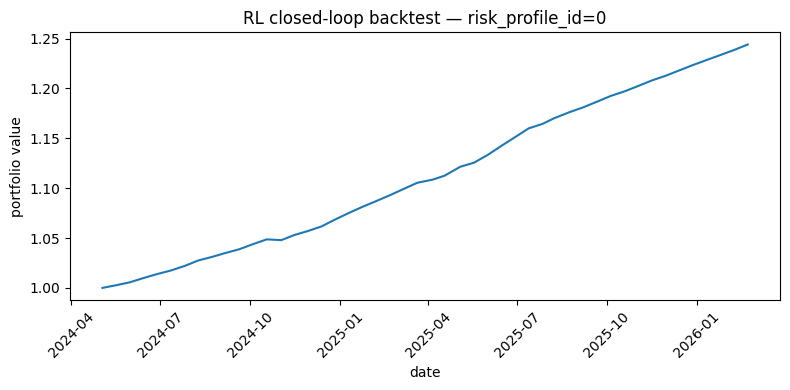

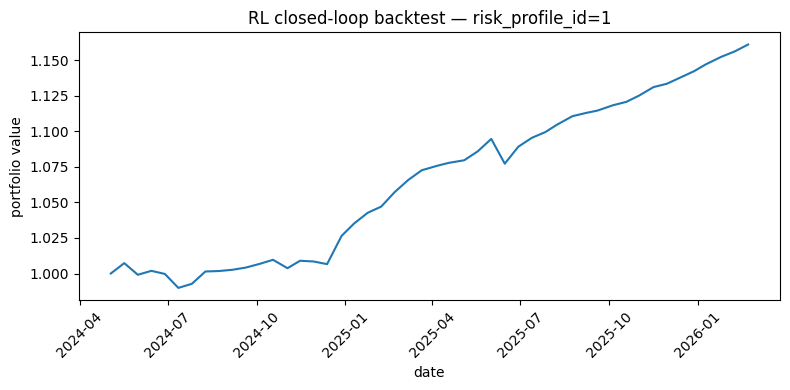

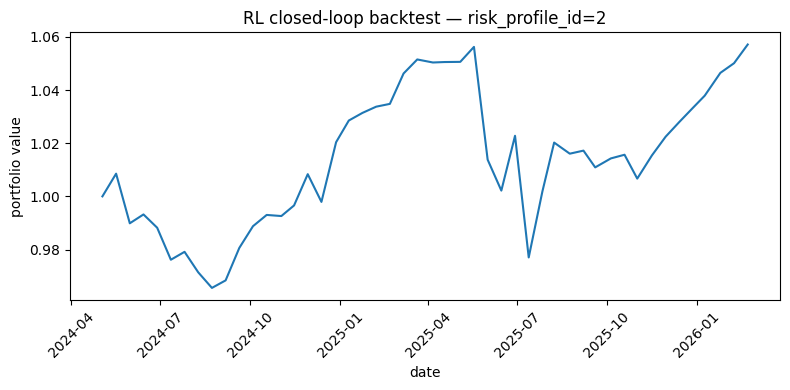

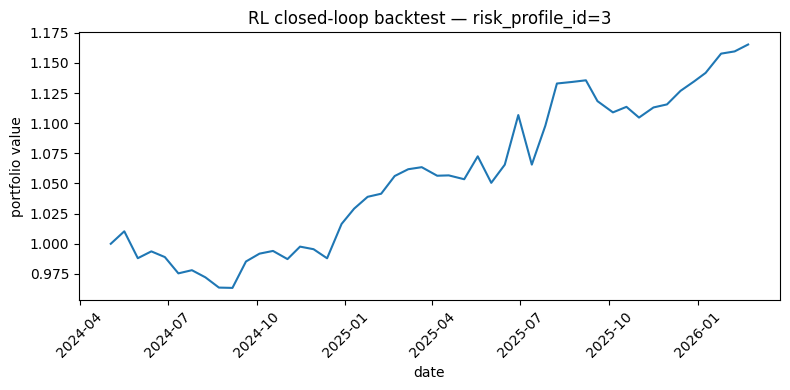

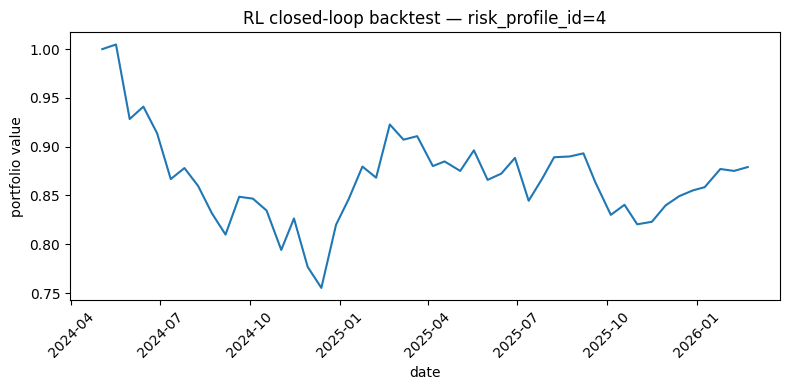

In [65]:
import matplotlib.pyplot as plt

for rp in sorted(rl_all_df["risk_profile_id"].unique()):
    grp = rl_all_df[rl_all_df["risk_profile_id"] == rp].sort_values("date")

    plt.figure(figsize=(8, 4))
    plt.plot(grp["date"], grp["value"])
    plt.title(f"RL closed-loop backtest — risk_profile_id={rp}")
    plt.xlabel("date")
    plt.ylabel("portfolio value")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [66]:
all_hold_results = []

for rp in sorted(test_states["risk_profile_id"].dropna().unique()):
    hold_df = backtest_hold_initial(risk_profile_id=int(rp), initial_value=1.0)
    hold_df["risk_profile_id"] = int(rp)
    all_hold_results.append(hold_df)

hold_all_df = pd.concat(all_hold_results, ignore_index=True)
hold_all_df.head()

,date,value,strategy,risk_profile_id
0,2024-05-03,1.000000,hold_initial,0
1,2024-05-17,1.000311,hold_initial,0
2,2024-05-31,0.998339,hold_initial,0
3,2024-06-14,0.999646,hold_initial,0
4,2024-06-28,1.000373,hold_initial,0


In [67]:
hold_final = (
    hold_all_df
    .sort_values(["risk_profile_id", "date"])
    .groupby("risk_profile_id")
    .tail(1)
    [["risk_profile_id", "date", "value"]]
    .rename(columns={"value": "hold_final_value"})
    .reset_index(drop=True)
)

rl_final = (
    rl_all_df
    .sort_values(["risk_profile_id", "date"])
    .groupby("risk_profile_id")
    .tail(1)
    [["risk_profile_id", "date", "value"]]
    .rename(columns={"value": "rl_final_value"})
    .reset_index(drop=True)
)

compare_final = hold_final.merge(rl_final, on=["risk_profile_id", "date"], how="outer")
print(compare_final)

   risk_profile_id       date  hold_final_value  rl_final_value
0                0 2026-02-22          1.091291        1.244106
1                1 2026-02-22          1.114407        1.161174
2                2 2026-02-22          1.110028        1.057113
3                3 2026-02-22          1.133964        1.165272
4                4 2026-02-22          0.976573        0.879139


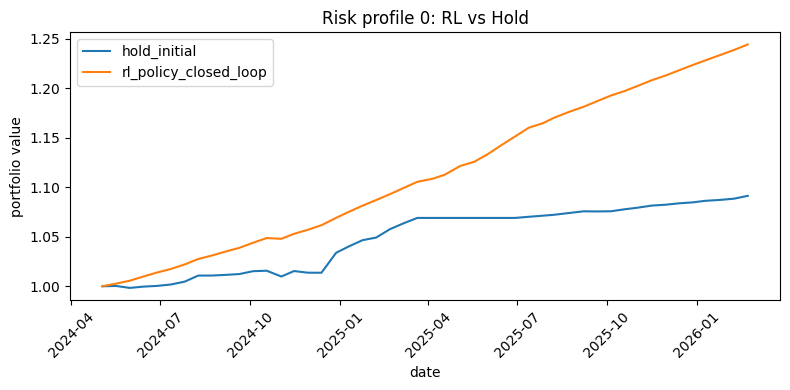

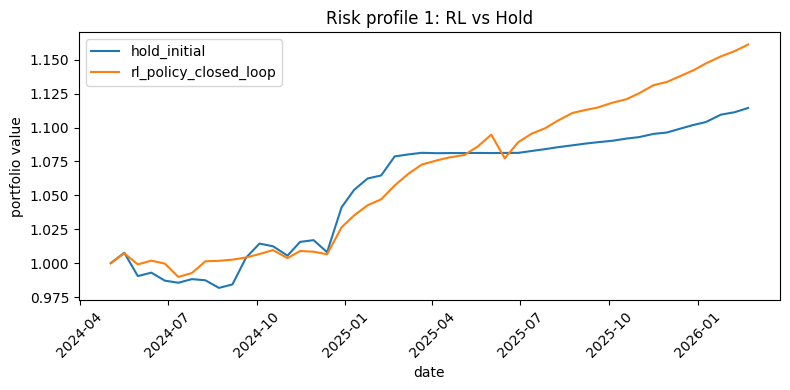

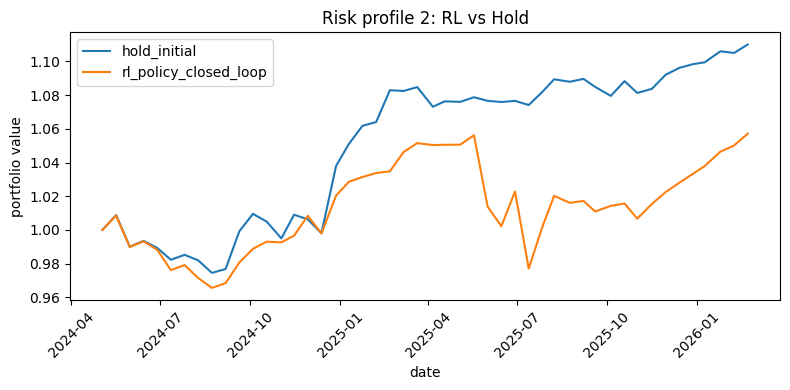

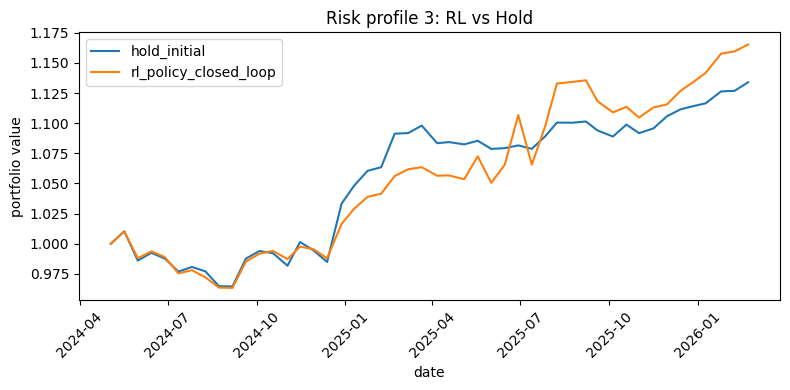

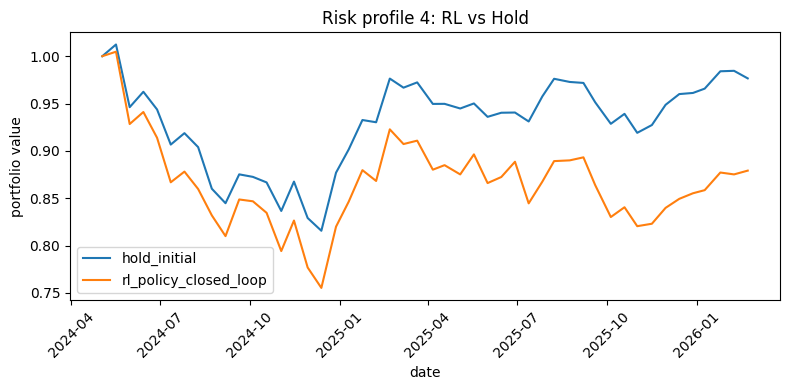

In [68]:
import matplotlib.pyplot as plt

for rp in sorted(test_states["risk_profile_id"].dropna().unique()):
    hold_grp = hold_all_df[hold_all_df["risk_profile_id"] == rp].sort_values("date")
    rl_grp = rl_all_df[rl_all_df["risk_profile_id"] == rp].sort_values("date")

    plt.figure(figsize=(8, 4))
    plt.plot(hold_grp["date"], hold_grp["value"], label="hold_initial")
    plt.plot(rl_grp["date"], rl_grp["value"], label="rl_policy_closed_loop")
    plt.title(f"Risk profile {rp}: RL vs Hold")
    plt.xlabel("date")
    plt.ylabel("portfolio value")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

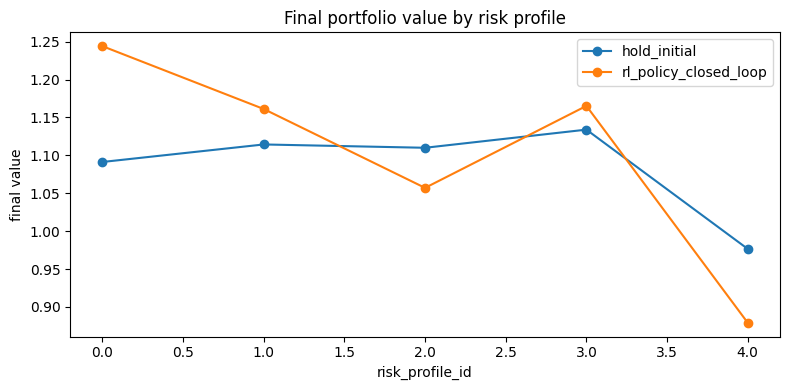

In [69]:
plt.figure(figsize=(8, 4))
x = compare_final["risk_profile_id"]

plt.plot(x, compare_final["hold_final_value"], marker="o", label="hold_initial")
plt.plot(x, compare_final["rl_final_value"], marker="o", label="rl_policy_closed_loop")

plt.title("Final portfolio value by risk profile")
plt.xlabel("risk_profile_id")
plt.ylabel("final value")
plt.legend()
plt.tight_layout()
plt.show()